In [1]:
# Experiment 7: Logistic Regression

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

# Dataset
data = pd.DataFrame({
    'Hours_Studied': [1,2,3,4,5,6,7,8,9,10,2,4,6,8,10],
    'Attendance': [50,55,60,65,70,75,80,85,90,95,52,68,78,88,96],
    'Pass': [0,0,0,0,1,1,1,1,1,1,0,0,1,1,1]
})

print("Dataset:")
print(data)

X = data[['Hours_Studied', 'Attendance']]
y = data['Pass']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("\nPredicted Values:")
print(y_pred)

print("\nActual Values:")
print(y_test.values)

print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Dataset:
    Hours_Studied  Attendance  Pass
0               1          50     0
1               2          55     0
2               3          60     0
3               4          65     0
4               5          70     1
5               6          75     1
6               7          80     1
7               8          85     1
8               9          90     1
9              10          95     1
10              2          52     0
11              4          68     0
12              6          78     1
13              8          88     1
14             10          96     1

Predicted Values:
[1 1 0 1 1]

Actual Values:
[1 0 0 1 1]

Accuracy: 0.8

Confusion Matrix:
[[1 1]
 [0 3]]


Dataset:
   Area  Price
0   500    150
1   600    180
2   700    210
3   800    240
4   900    270
5  1000    300
6  1100    330
7  1200    360
8  1300    390
9  1400    420

Predicted Prices:
[150. 180. 210. 240. 270. 300. 330. 360. 390. 420.]

Slope: 0.2999999999999998
Intercept: 1.7053025658242404e-13
R2 Score: 1.0
Mean Squared Error: 2.4233807008389483e-27


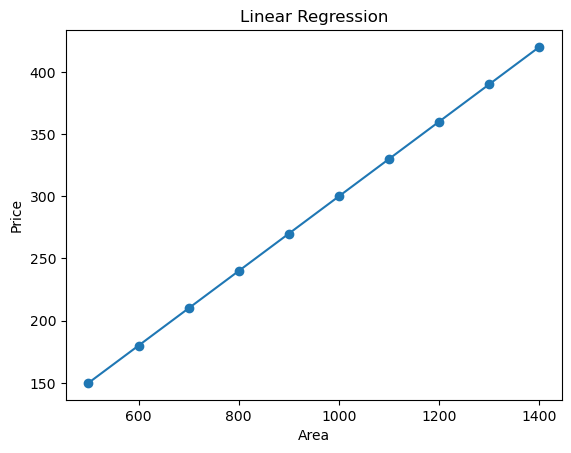


Predicted price for 1150 sq.ft: 344.99999999999994


C:\Users\Sk.Sameer\anaconda3\lib\site-packages\sklearn\base.py:420: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [2]:
# Experiment 8: Linear Regression

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Dataset
data = pd.DataFrame({
    'Area': [500, 600, 700, 800, 900, 1000, 1100, 1200, 1300, 1400],
    'Price': [150, 180, 210, 240, 270, 300, 330, 360, 390, 420]
})

print("Dataset:")
print(data)

X = data[['Area']]
y = data['Price']

model = LinearRegression()
model.fit(X, y)

y_pred = model.predict(X)

print("\nPredicted Prices:")
print(y_pred)

print("\nSlope:", model.coef_[0])
print("Intercept:", model.intercept_)
print("R2 Score:", r2_score(y, y_pred))
print("Mean Squared Error:", mean_squared_error(y, y_pred))

# Plot
plt.scatter(X, y)
plt.plot(X, y_pred)
plt.xlabel("Area")
plt.ylabel("Price")
plt.title("Linear Regression")
plt.show()

# Prediction
area = [[1150]]
print("\nPredicted price for 1150 sq.ft:", model.predict(area)[0])

Dataset:
   Experience  Salary
0           1      25
1           2      28
2           3      35
3           4      45
4           5      58
5           6      72
6           7      88
7           8     105
8           9     125
9          10     150

Linear Regression R2 Score: 0.9594124249897762
Polynomial Regression R2 Score: 0.9995116755103314


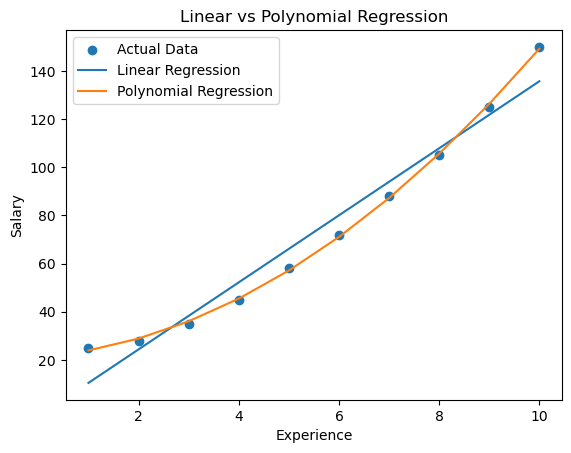

In [3]:
# Experiment 9: Linear and Polynomial Regression

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score

# Dataset
data = pd.DataFrame({
    'Experience': [1,2,3,4,5,6,7,8,9,10],
    'Salary': [25,28,35,45,58,72,88,105,125,150]
})

print("Dataset:")
print(data)

X = data[['Experience']]
y = data['Salary']

# Linear Regression
linear_model = LinearRegression()
linear_model.fit(X, y)
linear_pred = linear_model.predict(X)

# Polynomial Regression
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)

poly_model = LinearRegression()
poly_model.fit(X_poly, y)
poly_pred = poly_model.predict(X_poly)

print("\nLinear Regression R2 Score:",
      r2_score(y, linear_pred))

print("Polynomial Regression R2 Score:",
      r2_score(y, poly_pred))

# Plot
plt.scatter(X, y, label="Actual Data")
plt.plot(X, linear_pred, label="Linear Regression")
plt.plot(X, poly_pred, label="Polynomial Regression")

plt.xlabel("Experience")
plt.ylabel("Salary")
plt.title("Linear vs Polynomial Regression")
plt.legend()
plt.show()

Dataset:
[[1.  1.2]
 [1.2 1.5]
 [1.5 1.3]
 [1.8 1.7]
 [2.  1.9]
 [2.2 2. ]
 [7.  7.2]
 [7.3 7.5]
 [7.5 7.1]
 [7.8 7.9]
 [8.  8.2]
 [8.3 8. ]]


C:\Users\Sk.Sameer\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(



Cluster Labels:
[1 1 1 1 1 1 0 0 0 0 0 0]

Cluster Means:
[[7.65       7.65      ]
 [1.61666667 1.6       ]]


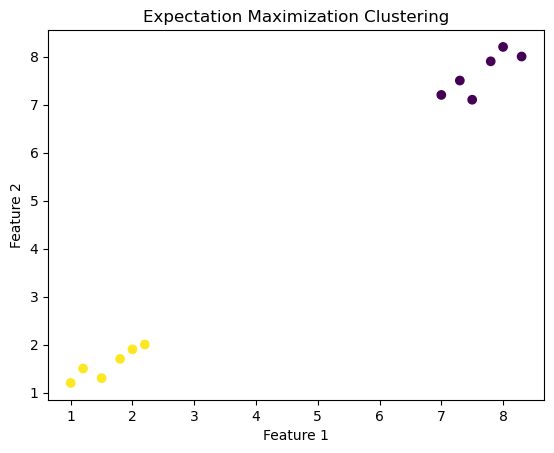

In [4]:
# Experiment 10: Expectation Maximization Algorithm

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture

# Dataset
data = np.array([
    [1.0, 1.2], [1.2, 1.5], [1.5, 1.3],
    [1.8, 1.7], [2.0, 1.9], [2.2, 2.0],
    [7.0, 7.2], [7.3, 7.5], [7.5, 7.1],
    [7.8, 7.9], [8.0, 8.2], [8.3, 8.0]
])

print("Dataset:")
print(data)

# Gaussian Mixture Model uses EM
model = GaussianMixture(n_components=2, random_state=42)
model.fit(data)

labels = model.predict(data)

print("\nCluster Labels:")
print(labels)

print("\nCluster Means:")
print(model.means_)

# Plot clusters
plt.scatter(data[:, 0], data[:, 1], c=labels)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Expectation Maximization Clustering")
plt.show()

In [5]:
# Experiment 11: Credit Score Classification

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

# Dataset
data = pd.DataFrame({
    'Age': [22,25,30,35,40,45,50,55,28,33,42,48,52,27,38],
    'Income': [20000,25000,30000,45000,50000,60000,70000,80000,
               28000,40000,55000,65000,75000,23000,48000],
    'Credit_History': [1,1,0,1,1,1,1,1,0,1,1,1,1,0,1],
    'Loans': [3,2,4,1,1,2,1,0,4,2,1,1,0,5,2],
    'Credit_Score': [
        'Poor','Poor','Poor','Good','Good',
        'Good','Excellent','Excellent','Poor',
        'Good','Good','Excellent','Excellent','Poor','Good'
    ]
})

print("Dataset:")
print(data)

le = LabelEncoder()
y = le.fit_transform(data['Credit_Score'])

X = data[['Age', 'Income', 'Credit_History', 'Loans']]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(
    y_test, y_pred, target_names=le.classes_, zero_division=0
))

Dataset:
    Age  Income  Credit_History  Loans Credit_Score
0    22   20000               1      3         Poor
1    25   25000               1      2         Poor
2    30   30000               0      4         Poor
3    35   45000               1      1         Good
4    40   50000               1      1         Good
5    45   60000               1      2         Good
6    50   70000               1      1    Excellent
7    55   80000               1      0    Excellent
8    28   28000               0      4         Poor
9    33   40000               1      2         Good
10   42   55000               1      1         Good
11   48   65000               1      1    Excellent
12   52   75000               1      0    Excellent
13   27   23000               0      5         Poor
14   38   48000               1      2         Good

Accuracy: 1.0

Classification Report:
              precision    recall  f1-score   support

   Excellent       1.00      1.00      1.00         1
        Goo

In [6]:
# Experiment 12: Iris Classification using KNN

import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

# Dataset included using sklearn
iris = load_iris()

data = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

data['Species'] = iris.target

print("Iris Dataset:")
print(data.head())

X = iris.data
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

model = KNeighborsClassifier(n_neighbors=5)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("\nAccuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Prediction
sample = [[5.1, 3.5, 1.4, 0.2]]
prediction = model.predict(sample)

print("\nPredicted Flower:",
      iris.target_names[prediction[0]])

Iris Dataset:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   Species  
0        0  
1        0  
2        0  
3        0  
4        0  

Accuracy: 1.0

Confusion Matrix:
[[19  0  0]
 [ 0 13  0]
 [ 0  0 13]]

Predicted Flower: setosa


In [7]:
# Experiment 13: Car Price Prediction

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Dataset
data = pd.DataFrame({
    'Year': [2015,2016,2017,2018,2019,2020,2021,2022,2016,2018,
             2019,2020,2021,2017,2019],
    'Kilometers': [80000,70000,60000,50000,40000,30000,20000,10000,
                   75000,45000,35000,28000,18000,65000,38000],
    'Engine_CC': [1200,1200,1500,1500,1600,1600,1800,2000,
                  1200,1500,1600,1600,1800,1400,1500],
    'Price': [4.0,4.5,5.2,6.0,7.0,8.0,10.0,12.0,
              4.3,6.2,7.3,8.2,10.5,5.0,7.0]
})

print("Car Dataset:")
print(data)

X = data[['Year', 'Kilometers', 'Engine_CC']]
y = data['Price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("\nPredicted Prices:")
print(y_pred)

print("\nR2 Score:", r2_score(y_test, y_pred))
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))

# Prediction
new_car = [[2022, 15000, 1800]]
print("\nPredicted price for new car:",
      model.predict(new_car)[0], "Lakhs")

Car Dataset:
    Year  Kilometers  Engine_CC  Price
0   2015       80000       1200    4.0
1   2016       70000       1200    4.5
2   2017       60000       1500    5.2
3   2018       50000       1500    6.0
4   2019       40000       1600    7.0
5   2020       30000       1600    8.0
6   2021       20000       1800   10.0
7   2022       10000       2000   12.0
8   2016       75000       1200    4.3
9   2018       45000       1500    6.2
10  2019       35000       1600    7.3
11  2020       28000       1600    8.2
12  2021       18000       1800   10.5
13  2017       65000       1400    5.0
14  2019       38000       1500    7.0

Predicted Prices:
[6.23  7.366 4.468 5.008 7.306]

R2 Score: 0.8964131079478044
Mean Squared Error: 0.27943600000000296

Predicted price for new car: 10.73 Lakhs


C:\Users\Sk.Sameer\anaconda3\lib\site-packages\sklearn\base.py:420: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


In [8]:
# Experiment 14: House Price Prediction

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

# Dataset
data = pd.DataFrame({
    'Area': [800,1000,1200,1400,1600,1800,2000,2200,2400,2600,
             900,1100,1500,1900,2300],
    'Bedrooms': [2,2,3,3,3,3,4,4,4,5,2,2,3,4,4],
    'Bathrooms': [1,2,2,2,2,3,3,3,4,4,1,2,2,3,3],
    'Age': [15,12,10,8,7,6,5,4,3,2,14,11,9,5,4],
    'Price': [35,45,55,65,75,85,100,115,130,150,
              40,50,70,95,125]
})

print("House Dataset:")
print(data)

X = data[['Area', 'Bedrooms', 'Bathrooms', 'Age']]
y = data['Price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("\nPredicted Prices:")
print(y_pred)

print("\nR2 Score:", r2_score(y_test, y_pred))
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))

# Prediction
new_house = [[1800, 3, 2, 5]]

print("\nPredicted House Price:",
      model.predict(new_house)[0], "Lakhs")

House Dataset:
    Area  Bedrooms  Bathrooms  Age  Price
0    800         2          1   15     35
1   1000         2          2   12     45
2   1200         3          2   10     55
3   1400         3          2    8     65
4   1600         3          2    7     75
5   1800         3          3    6     85
6   2000         4          3    5    100
7   2200         4          3    4    115
8   2400         4          4    3    130
9   2600         5          4    2    150
10   900         2          1   14     40
11  1100         2          2   11     50
12  1500         3          2    9     70
13  1900         4          3    5     95
14  2300         4          3    4    125

Predicted Prices:
[124.85  47.8   42.25 103.9   86.35]

R2 Score: 0.9039903486924035
Mean Squared Error: 154.19150000000008

Predicted House Price: 82.45 Lakhs


C:\Users\Sk.Sameer\anaconda3\lib\site-packages\sklearn\base.py:420: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
